<a href="https://colab.research.google.com/github/JayadharsiniMathiyalagan/Fundamentals-of-Machine-Learning/blob/main/FOML_EXP_8(b).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

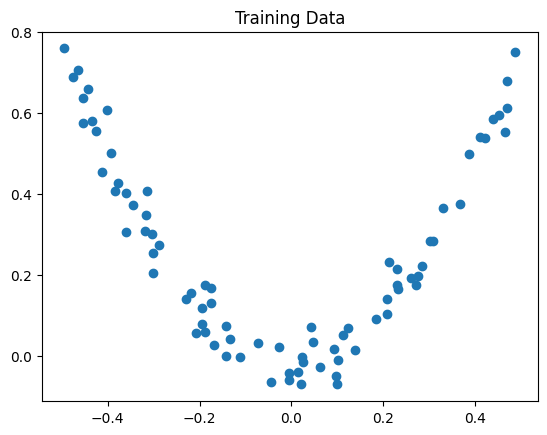

Initial prediction (F0): 0.2552561255322317
Round 1 completed
Round 2 completed
Round 3 completed
Round 4 completed
Round 5 completed

Training MSE: 0.0011725007297622412
Testing MSE: 0.0029711541824222623


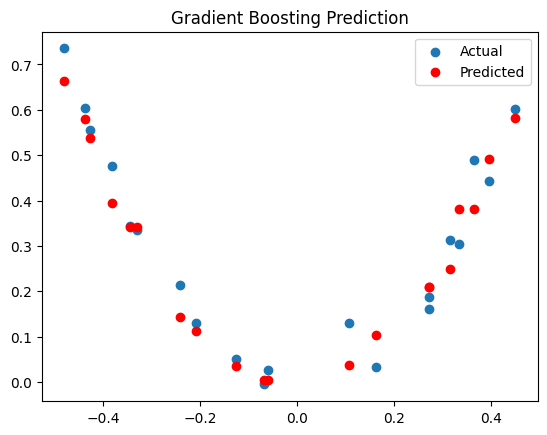

In [10]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ==============================
# STEP 2: Prepare Data
# ==============================
np.random.seed(42)

X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Plot initial data
plt.scatter(X_train, y_train)
plt.title("Training Data")
plt.show()

# ==============================
# STEP 3: Initialize Parameters
# ==============================
n_estimators = 5
learning_rate = 0.5

trees = []

# ==============================
# STEP 4: Base Model
# ==============================
F0 = np.mean(y_train)
F = np.full_like(y_train, F0)

print("Initial prediction (F0):", F0)

# ==============================
# STEP 5: Gradient Boosting Loop
# ==============================
for i in range(n_estimators):

    # Compute residuals
    residuals = y_train - F

    # Train weak learner
    tree = DecisionTreeRegressor(max_depth=3)
    tree.fit(X_train, residuals)

    # Predict residuals
    pred = tree.predict(X_train)

    # Update prediction
    F = F + learning_rate * pred

    # Store model
    trees.append(tree)

    print(f"Round {i+1} completed")

# ==============================
# STEP 6: Prediction on Test Data
# ==============================
F_test = np.full_like(y_test, F0)

for tree in trees:
    F_test += learning_rate * tree.predict(X_test)

# ==============================
# STEP 7: Evaluation
# ==============================
train_mse = mean_squared_error(y_train, F)
test_mse = mean_squared_error(y_test, F_test)

print("\nTraining MSE:", train_mse)
print("Testing MSE:", test_mse)

# ==============================
# STEP 8: Visualization
# ==============================
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, F_test, color='red', label="Predicted")
plt.legend()
plt.title("Gradient Boosting Prediction")
plt.show()